Տնային առաջադրանքը կատարելու վերջնաժամկետը **31.05.2021 15:30** է։ Առաջադրանքները կատարելուց հետո, պետք է 

1. ներբեռնեք այս ֆայլը ձեր համակարգիչ (`File` $\to$ `Download .ipynb`)
 
2. ներբեռնեք լրացված ``.py`` ֆայլերը
 
3. վերոնշյալ ֆայլերը ``.zip`` արեք և վերնագրեք հետևյալ ֆորմատով՝ 
    *HW2_AnunAzganunyan.zip* 
 
4. ուղարկեք ֆայլը **fast.1991.ml@gmail.com** հասցեին` նամակի թեմա (subject) դաշտում գրելով **ML2**
 
5. տնայինը կրկին անգամ ուղարկելու դեպքում պատասխանել (reply/ответить) նախորդ նամակին 
 
**Ուշադրություն**․ 
Վերոնշյալ պայմաններին չբավարարելու դեպքում ձեր աշխատանքը չի գնահատվի։

# Decision Trees

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid') # Plot style
plt.rcParams['figure.figsize'] = (12.0, 8.0)

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload 2

Complete the incomplete parts in `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab2/decision_tree.py` script and import the `DTClassifier`. If you have never used recursive functions in python before, you may want to read [this](https://realpython.com/python-thinking-recursively/) or any similar tutorial to have more idea about the recursive functions in the code. 

The dataset that we will work with, is the famous Titanic dataset from [kaggle](https://www.kaggle.com/c/titanic) and a copy of it can be found in `Courses 3rd batch/MachineLearning/Labs/Lab_files/Lab2/train.csv`.

In [2]:
from decision_tree import DTClassifier

##Dataset 1

In [3]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
df.shape

(891, 12)

In [4]:
data = df[['Pclass', 'Sex', 'Survived']]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(data.drop(columns='Survived'),
                                                    data[['Survived']],
                                                    random_state=0)

In [6]:
model = DTClassifier(impurity='gini')
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.7802690582959642

In [7]:
model = DTClassifier(impurity='entropy')
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.7802690582959642

You should get about $78\%$ accuracy in both cases.

In [8]:
data_with_age = df[['Pclass', 'Sex', 'Age', 'Survived']]

In [15]:
data_with_age.isna().sum()

Pclass        0
Sex           0
Age         177
Survived      0
dtype: int64

Let's remove the rows with missing data.

In [9]:
data_with_age = data_with_age.dropna()

In [17]:
data_with_age.shape

(714, 4)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(data_with_age.drop(columns='Survived'),
                                                    data_with_age.Survived,
                                                    random_state=0)

In [11]:
model = DTClassifier(impurity='gini')
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8044692737430168

In [12]:
model = DTClassifier(impurity='entropy')
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8044692737430168

Here you should get about $80\%$ accuracy in both cases.

Let's compare with sklearn's implementation as always. We need to encode the non-numeric features first.

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
data1 = pd.get_dummies(data, drop_first=True)
X_train1, X_test1, y_train, y_test = train_test_split(data1.drop(columns='Survived'),
                                                      data1.Survived,
                                                      random_state=0)

In [50]:
data1.head()

,Pclass,Survived,Sex_male
0,3,0,1
1,1,1,0
2,3,1,0
3,1,1,0
4,3,0,1


In [51]:
X_train1.head()

,Pclass,Sex_male
105,3,1
68,3,0
253,3,1
320,3,1
706,2,0


In [15]:
model1 = DecisionTreeClassifier(criterion='gini')
model1.fit(X_train1, y_train)
prediction1 = model1.predict(X_test1)
accuracy_score(prediction1, y_test)

0.7802690582959642

In [16]:
model1 = DecisionTreeClassifier(criterion='entropy')
model1.fit(X_train1, y_train)
prediction1 = model1.predict(X_test1)
accuracy_score(prediction1, y_test)

0.7802690582959642

Here you should get about $78\%$ accuracy in both cases.

Now let's see the case with `Age` variable.

In [17]:
data2 = pd.get_dummies(data_with_age, drop_first=True)
X_train2, X_test2, y_train, y_test = train_test_split(data2.drop(columns='Survived'),
                                                      data2.Survived,
                                                      random_state=0)

In [18]:
model1 = DecisionTreeClassifier(criterion='gini')
model1.fit(X_train2, y_train)
prediction1 = model1.predict(X_test2)
accuracy_score(prediction1, y_test)

0.7932960893854749

Here you should get about $79\%$ accuracy.

Experiment with your implementation to train a good model on this training dataset. Try different values for the hyperparameters.

##Dataset 2

This dataset shows whether the applicant has been involved in the 1991 unit courses.

Columns:
* `Pass` - 1 if has been involved, 0 otherwise
* `Age` - age of the applicant
* `Education type` - educational level of the applicant
* `Educational institution name` - exact place of study
* `Programming languages` - what languages the applicant know

In [19]:
# Reading data from dataset.csv
df2 = pd.read_csv("dataset.csv").astype('category')
df2

,Pass,Age,Education type,Educational institution name,Programming languages
0,0,19,High school,Other,"Python, Java Script, C++, C, Other"
1,0,18,High school,Eurnekian school,"Python, Java Script"
2,0,17,High school,NPUA,"Python, Other"
3,0,1,Bachelor,Other,No
4,0,23,Master,No,Java Script
...,...,...,...,...,...
402,0,21,Bachelor,RAU,Java
403,0,18,High school,Ayb,"Python, Java Script, C++, Other"
404,0,18,High school,Physmath,Other
405,0,17,High school,Real school,"Python, Java Script"


In [57]:
# from google.colab import drive
# drive.mount('/content/drive')

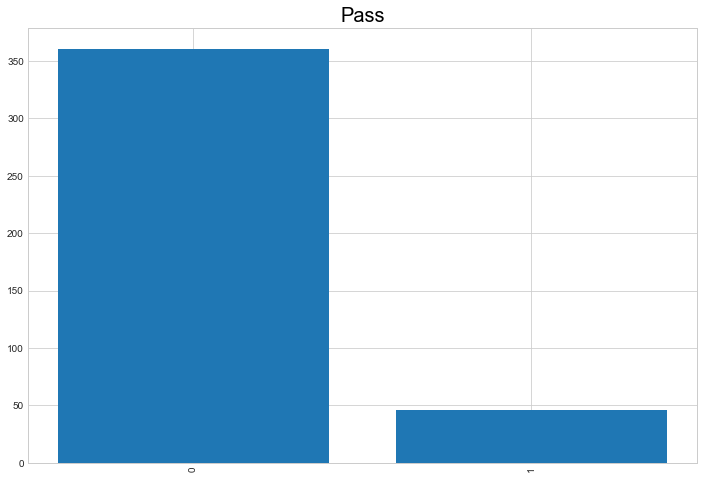

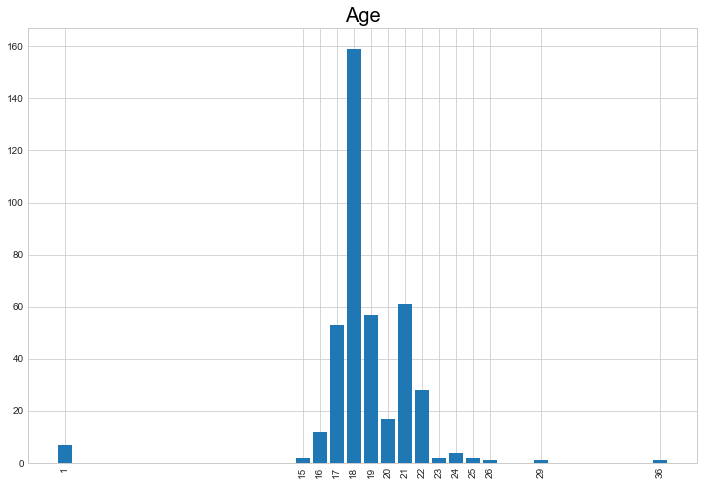

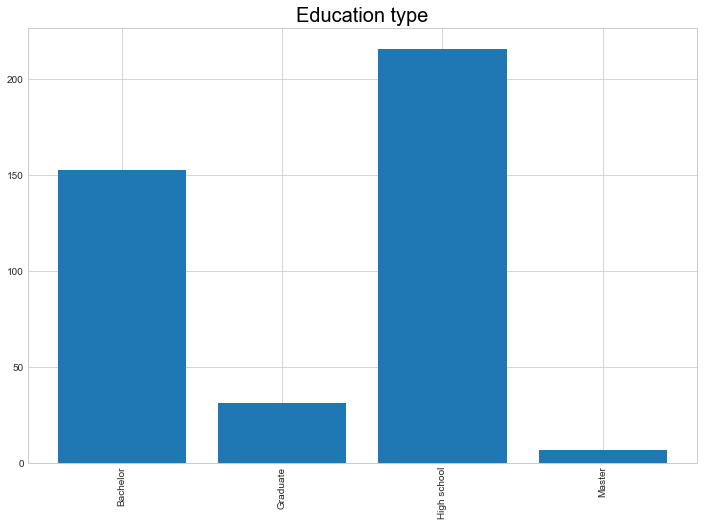

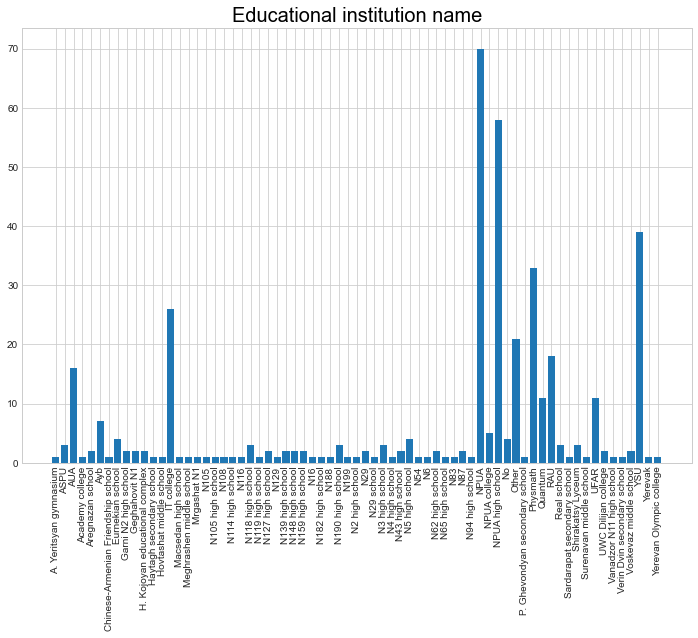

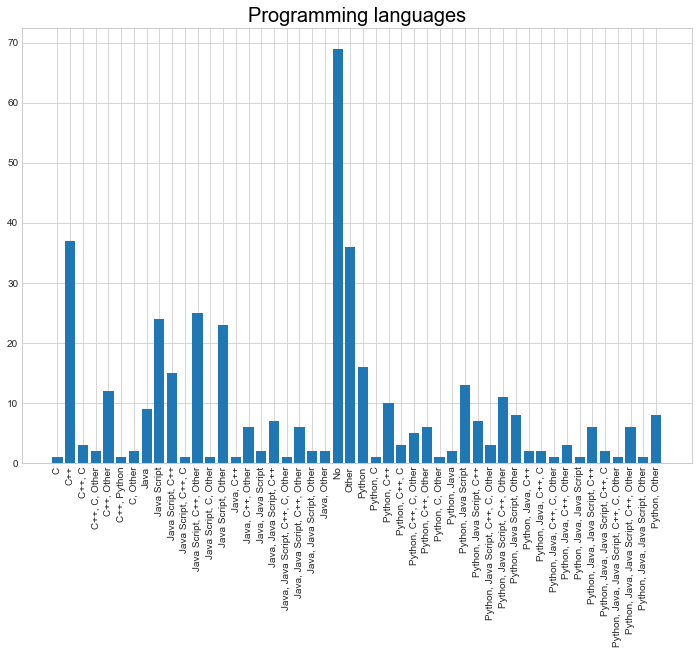

In [28]:
# Write code to see each column distribution
##### YOUR CODE STARTS HERE#####
font = {'color':  'black',
        'size': 20}
    
for i in range(len(df2.columns)):
  b = list (df2[df2.columns[i]])
  a = list (df2[df2.columns[i]].unique())
  a.sort()
  hight = []
  for j in a:
    hight.append(b.count(j))
  plt.bar(a,hight)
  plt.xticks(a, a, rotation=90)
  plt.title(df2.columns[i], fontdict = font )
  plt.show()


##### YOUR CODE ENDS HERE #####

In [20]:
X_train, X_test, y_train, y_test = train_test_split(df2.drop(columns='Pass'),
                                                    df2.Pass,
                                                    random_state=0)

Our implementation

In [21]:
model = DTClassifier()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8725490196078431

Here you should get about $87.25\%$ accuracy in both cases.

Sklearn implementation

In [22]:
# Change `df2` so the error in cell below will be fixed
##### YOUR CODE STARTS HERE#####
col = df2.columns
b = np.array(df2)
d = {}
ind = 2
for s in df2.columns[2 :]:
    
    n = list (df2[s].unique())
    for j in n:
        d[j] = n.index(j)
        
for s in df2.columns[2 :]:    
    for i in range(len(b[:, ind])):    
        b[i,ind] = d[b[i,ind]]
    ind += 1


df2 = pd.DataFrame(b,columns=col, dtype='float64')
df2
##### YOUR CODE ENDS HERE #####

,Pass,Age,Education type,Educational institution name,Programming languages
0,0.0,19.0,0.0,8.0,0.0
1,0.0,18.0,0.0,1.0,1.0
2,0.0,17.0,0.0,2.0,2.0
3,0.0,1.0,1.0,8.0,3.0
4,0.0,23.0,2.0,3.0,4.0
...,...,...,...,...,...
402,0.0,21.0,1.0,14.0,18.0
403,0.0,18.0,0.0,61.0,9.0
404,0.0,18.0,0.0,7.0,8.0
405,0.0,17.0,0.0,42.0,1.0


In [23]:
# This will show error, fix it in cell above
X_train, X_test, y_train, y_test = train_test_split(df2.drop(columns='Pass'),
                                                    df2.Pass,
                                                    random_state=0)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8529411764705882

Think about how we can modify the dataset so that it depends on each programming language separately

In [24]:
##### YOUR CODE STARTS HERE#####
# So we can drop the column Programming languages and insted add mutiple columns with name of specific proggramming languages.
df2 = pd.read_csv("dataset.csv").astype('category')#this is beause previous 2 cells changes the df2 DataFrame

def specific_lang(data, prog_languages):
    for i in prog_languages:
        k = []
        for j in data['Programming languages']:
            if i in j:
                k.append(1)
            else:
                k.append(0)

        data[i] = k
    data.drop("Programming languages", axis=1)
## this is for  encoding feature values
    col = data.columns
    b = np.array(data)
    d = {}
    ind = 2
    for s in data.columns[2 :]:

        n = list (data[s].unique())
        for j in n:
            d[j] = n.index(j)

    for s in data.columns[2 :]:    
        for i in range(len(b[:, ind])):    
            b[i,ind] = d[b[i,ind]]
        ind += 1


    data = pd.DataFrame(b,columns=col, dtype='float64')


    return data

l = ['Python', 'Java', 'Script', 'C++', 'C', 'Java', 'Other']
df2 = specific_lang(df2, l)
df2
##### YOUR CODE ENDS HERE #####

,Pass,Age,Education type,Educational institution name,Programming languages,Python,Java,Script,C++,C,Other
0,0.0,19.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,18.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
2,0.0,17.0,0.0,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0
3,0.0,1.0,1.0,8.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0
4,0.0,23.0,2.0,3.0,4.0,1.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
402,0.0,21.0,1.0,14.0,18.0,1.0,0.0,1.0,1.0,1.0,1.0
403,0.0,18.0,0.0,61.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0
404,0.0,18.0,0.0,7.0,8.0,1.0,1.0,1.0,1.0,1.0,0.0
405,0.0,17.0,0.0,42.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0


In [25]:
X_train, X_test, y_train, y_test = train_test_split(df2.drop(columns='Pass'),
                                                    df2.Pass,
                                                    random_state=0)

Our implementation

In [26]:
model = DTClassifier()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8921568627450981

Sklearn implementation

In [27]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8431372549019608

Try to get better accuracy by changing classifier parameters

In [28]:
params = {
    'impurity': 'gini',
    'min_impurity' : 1,
    'min_samples_split' : 5

  
}

In [29]:
model = DTClassifier(**params)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8725490196078431

In [30]:
params_sk = {
  'criterion': 'gini',
    'min_impurity_decrease' : 1
    
  
}

In [31]:
model = DecisionTreeClassifier(**params_sk)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy_score(prediction, y_test)

0.8725490196078431